# Hotel Bar Inventory Forecasting & Par-Level Recommendation System

## AI Engineer Take-Home Assignment

### Project Objective

This project develops an end-to-end forecasting and inventory recommendation
system for hotel bars.

The system aims to:

- Forecast item-level demand for each bar location.
- Identify high- and low-velocity products.
- Estimate inventory requirements during supplier lead time.
- Calculate safety stock to protect against demand uncertainty.
- Recommend appropriate inventory par levels.
- Simulate the recommended inventory policy using historical demand.
- Provide actionable insights for hotel managers.

### Business Goal

The primary business objective is to reduce stockouts of high-demand items
while avoiding unnecessary overstocking of slow-moving products.

The solution combines exploratory data analysis, time-series forecasting,
machine learning, inventory planning, and historical simulation.

## 1. Business Problem

The hotel chain operates multiple bars across different locations and
experiences two major inventory problems:

1. Stockouts of high-demand products can affect product availability,
   guest satisfaction, and potential sales.

2. Overstocking slow-moving products increases inventory holding costs
   and ties up storage capacity.

The objective is to develop a data-driven system that forecasts future
item-level demand and converts the forecast into practical inventory
par-level recommendations for each bar location.

The system should balance expected demand with uncertainty so that managers
maintain sufficient stock without unnecessarily increasing inventory.

## 2. Project Objectives

The project has the following objectives:

1. Understand the structure and quality of the historical inventory data.
2. Validate inventory movement calculations.
3. Convert transaction-level records into daily demand.
4. Analyze demand patterns across bars and brands.
5. Identify high-, medium-, and low-velocity products.
6. Analyze potential stockout patterns.
7. Build demand forecasting models.
8. Evaluate forecasting performance using time-based validation.
9. Calculate safety stock based on demand variability.
10. Recommend inventory par levels.
11. Simulate the recommended inventory policy.
12. Compare operational metrics such as stockouts, lost demand, and inventory.
13. Provide practical recommendations for real hotel operations.

In [202]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from sklearn.ensemble import RandomForestRegressor

from statsmodels.tsa.holtwinters import ExponentialSmoothing

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [203]:
import os

files_in_colab = os.listdir("/content")

print("Files available in Colab:")
for file in files_in_colab:
    print(file)

Files available in Colab:
.config
Consumption Dataset - Dataset.csv
sample_data


In [204]:
file_path = "/content/Consumption Dataset - Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [205]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6575
Number of columns: 8


In [206]:
display(df.head(10))

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90
5,1/1/2023 10:28,Brown's Bar,Vodka,Grey Goose,2560.44,0.00,0.0,2560.44
6,1/1/2023 14:47,Brown's Bar,Whiskey,Jim Beam,826.20,0.00,0.0,826.20
7,1/1/2023 18:34,Brown's Bar,Rum,Captain Morgan,2330.03,0.00,0.0,2330.03
8,1/1/2023 17:23,Taylor's Bar,Vodka,Absolut,1736.08,0.00,0.0,1736.08
9,1/1/2023 17:33,Taylor's Bar,Whiskey,Jack Daniels,2254.32,0.00,0.0,2254.32


In [207]:
print("Column names:")
print()

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Column names:

1. Date Time Served
2. Bar Name
3. Alcohol Type
4. Brand Name
5. Opening Balance (ml)
6. Purchase (ml)
7. Consumed (ml)
8. Closing Balance (ml)


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   object 
 1   Bar Name              6575 non-null   object 
 2   Alcohol Type          6575 non-null   object 
 3   Brand Name            6575 non-null   object 
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), object(4)
memory usage: 411.1+ KB


In [209]:
display(df.describe())

,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
count,6575.000000,6575.000000,6575.000000,6575.000000
mean,2468.397180,315.841757,299.419264,2484.811748
std,2284.552895,582.120264,191.903874,2302.363298
min,0.000000,0.000000,0.000000,0.000000
25%,619.135000,0.000000,156.640000,611.000000
50%,1848.440000,0.000000,300.390000,1849.840000
75%,3853.020000,526.345000,450.870000,3906.050000
max,11862.520000,1999.840000,1180.580000,11862.520000


In [210]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (
        df.isnull().mean() * 100
    ).round(2)
})

display(missing_summary)

,Missing Count,Missing Percentage
Date Time Served,0,0.0
Bar Name,0,0.0
Alcohol Type,0,0.0
Brand Name,0,0.0
Opening Balance (ml),0,0.0
Purchase (ml),0,0.0
Consumed (ml),0,0.0
Closing Balance (ml),0,0.0


In [211]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [212]:
for column in df.columns:
    print(
        f"{column}:",
        df[column].nunique(),
        "unique values"
    )

Date Time Served: 6497 unique values
Bar Name: 6 unique values
Alcohol Type: 5 unique values
Brand Name: 16 unique values
Opening Balance (ml): 5506 unique values
Purchase (ml): 1668 unique values
Consumed (ml): 5391 unique values
Closing Balance (ml): 5498 unique values


In [213]:
print("Bars:")
display(df["Bar Name"].unique())

print("\nAlcohol Types:")
display(df["Alcohol Type"].unique())

print("\nNumber of Brands:")
print(df["Brand Name"].nunique())

print("\nBrands:")
display(df["Brand Name"].unique())

Bars:


array(["Smith's Bar", "Johnson's Bar", "Brown's Bar", "Taylor's Bar",
       "Anderson's Bar", "Thomas's Bar"], dtype=object)


Alcohol Types:


array(['Rum', 'Wine', 'Vodka', 'Beer', 'Whiskey'], dtype=object)


Number of Brands:
16

Brands:


array(['Captain Morgan', 'Yellow Tail', 'Grey Goose', 'Coors', 'Jim Beam',
       'Absolut', 'Jack Daniels', 'Sutter Home', 'Miller', 'Bacardi',
       'Malibu', 'Jameson', 'Smirnoff', 'Budweiser', 'Heineken',
       'Barefoot'], dtype=object)

## 3. Data Quality Assessment

Before developing the forecasting model, the dataset is checked for:

- Missing values
- Duplicate records
- Invalid data types
- Negative inventory quantities
- Date parsing issues
- Inventory balance inconsistencies

These checks are performed before forecasting because data-quality problems
can directly affect demand estimates and inventory recommendations.

##Data Preprocessing

In [214]:
df["Date Time Served"] = pd.to_datetime(
    df["Date Time Served"],
    errors="coerce"
)

print("Invalid dates:", df["Date Time Served"].isna().sum())

print(
    "Earliest date:",
    df["Date Time Served"].min()
)

print(
    "Latest date:",
    df["Date Time Served"].max()
)

Invalid dates: 0
Earliest date: 2023-01-01 10:07:00
Latest date: 2024-01-01 22:46:00


In [215]:
df["Date"] = (
    df["Date Time Served"]
    .dt.floor("D")
)

df["DayOfWeek"] = (
    df["Date Time Served"]
    .dt.day_name()
)

df["Month"] = (
    df["Date Time Served"]
    .dt.month
)

df["IsWeekend"] = (
    df["Date Time Served"]
    .dt.dayofweek
    .isin([4, 5, 6])
    .astype(int)
)

display(
    df[
        [
            "Date Time Served",
            "Date",
            "DayOfWeek",
            "Month",
            "IsWeekend"
        ]
    ].head()
)

,Date Time Served,Date,DayOfWeek,Month,IsWeekend
0,2023-01-01 19:35:00,2023-01-01,Sunday,1,1
1,2023-01-01 10:07:00,2023-01-01,Sunday,1,1
2,2023-01-01 11:26:00,2023-01-01,Sunday,1,1
3,2023-01-01 13:53:00,2023-01-01,Sunday,1,1
4,2023-01-01 22:28:00,2023-01-01,Sunday,1,1


In [216]:
df["Expected Closing Balance"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Balance Difference"] = (
    df["Closing Balance (ml)"]
    - df["Expected Closing Balance"]
)

df["Absolute Difference"] = (
    df["Balance Difference"].abs()
)

display(
    df[
        [
            "Opening Balance (ml)",
            "Purchase (ml)",
            "Consumed (ml)",
            "Closing Balance (ml)",
            "Expected Closing Balance",
            "Balance Difference"
        ]
    ].head(10)
)

,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing Balance,Balance Difference
0,2555.04,1824.84,0.0,4379.88,4379.88,0.0
1,1344.37,0.00,0.0,1344.37,1344.37,0.0
2,1034.28,0.00,0.0,1034.28,1034.28,0.0
3,2194.53,0.00,0.0,2194.53,2194.53,0.0
4,1020.90,0.00,0.0,1020.90,1020.90,0.0
5,2560.44,0.00,0.0,2560.44,2560.44,0.0
6,826.20,0.00,0.0,826.20,826.20,0.0
7,2330.03,0.00,0.0,2330.03,2330.03,0.0
8,1736.08,0.00,0.0,1736.08,1736.08,0.0
9,2254.32,0.00,0.0,2254.32,2254.32,0.0


In [217]:
tolerance = 0.1

inventory_issues = df[
    df["Absolute Difference"] > tolerance
]

print(
    "Inventory records with differences:",
    len(inventory_issues)
)

print(
    "Percentage of records with differences:",
    round(
        len(inventory_issues) / len(df) * 100,
        2
    ),
    "%"
)

Inventory records with differences: 141
Percentage of records with differences: 2.14 %


In [218]:
inventory_columns = [
    "Opening Balance (ml)",
    "Purchase (ml)",
    "Consumed (ml)",
    "Closing Balance (ml)"
]

for column in inventory_columns:
    negative_count = (df[column] < 0).sum()

    print(
        f"{column}: {negative_count} negative values"
    )

Opening Balance (ml): 0 negative values
Purchase (ml): 0 negative values
Consumed (ml): 0 negative values
Closing Balance (ml): 0 negative values


In [219]:
data = df.copy()

print("Original dataset shape:", df.shape)
print("Working dataset shape:", data.shape)

Original dataset shape: (6575, 15)
Working dataset shape: (6575, 15)


In [220]:
data

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Date,DayOfWeek,Month,IsWeekend,Expected Closing Balance,Balance Difference,Absolute Difference
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2.555040e+03,1824.84,0.00,4379.88,2023-01-01,Sunday,1,1,4379.88,0.000000e+00,0.000000e+00
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1.344370e+03,0.00,0.00,1344.37,2023-01-01,Sunday,1,1,1344.37,0.000000e+00,0.000000e+00
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1.034280e+03,0.00,0.00,1034.28,2023-01-01,Sunday,1,1,1034.28,0.000000e+00,0.000000e+00
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2.194530e+03,0.00,0.00,2194.53,2023-01-01,Sunday,1,1,2194.53,0.000000e+00,0.000000e+00
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1.020900e+03,0.00,0.00,1020.90,2023-01-01,Sunday,1,1,1020.90,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6570,2024-01-01 21:03:00,Anderson's Bar,Beer,Coors,2.467080e+03,0.00,321.06,2146.02,2024-01-01,Monday,1,0,2146.02,0.000000e+00,0.000000e+00
6571,2024-01-01 21:15:00,Anderson's Bar,Rum,Malibu,8.530000e-14,1743.64,175.05,1568.59,2024-01-01,Monday,1,0,1568.59,-2.273737e-13,2.273737e-13
6572,2024-01-01 18:34:00,Anderson's Bar,Whiskey,Jack Daniels,4.192660e+03,0.00,197.60,3995.06,2024-01-01,Monday,1,0,3995.06,0.000000e+00,0.000000e+00
6573,2024-01-01 22:46:00,Thomas's Bar,Vodka,Absolut,2.424950e+03,0.00,128.52,2296.43,2024-01-01,Monday,1,0,2296.43,0.000000e+00,0.000000e+00


In [221]:
df

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Date,DayOfWeek,Month,IsWeekend,Expected Closing Balance,Balance Difference,Absolute Difference
0,2023-01-01 19:35:00,Smith's Bar,Rum,Captain Morgan,2.555040e+03,1824.84,0.00,4379.88,2023-01-01,Sunday,1,1,4379.88,0.000000e+00,0.000000e+00
1,2023-01-01 10:07:00,Smith's Bar,Wine,Yellow Tail,1.344370e+03,0.00,0.00,1344.37,2023-01-01,Sunday,1,1,1344.37,0.000000e+00,0.000000e+00
2,2023-01-01 11:26:00,Johnson's Bar,Vodka,Grey Goose,1.034280e+03,0.00,0.00,1034.28,2023-01-01,Sunday,1,1,1034.28,0.000000e+00,0.000000e+00
3,2023-01-01 13:53:00,Johnson's Bar,Beer,Coors,2.194530e+03,0.00,0.00,2194.53,2023-01-01,Sunday,1,1,2194.53,0.000000e+00,0.000000e+00
4,2023-01-01 22:28:00,Johnson's Bar,Wine,Yellow Tail,1.020900e+03,0.00,0.00,1020.90,2023-01-01,Sunday,1,1,1020.90,0.000000e+00,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6570,2024-01-01 21:03:00,Anderson's Bar,Beer,Coors,2.467080e+03,0.00,321.06,2146.02,2024-01-01,Monday,1,0,2146.02,0.000000e+00,0.000000e+00
6571,2024-01-01 21:15:00,Anderson's Bar,Rum,Malibu,8.530000e-14,1743.64,175.05,1568.59,2024-01-01,Monday,1,0,1568.59,-2.273737e-13,2.273737e-13
6572,2024-01-01 18:34:00,Anderson's Bar,Whiskey,Jack Daniels,4.192660e+03,0.00,197.60,3995.06,2024-01-01,Monday,1,0,3995.06,0.000000e+00,0.000000e+00
6573,2024-01-01 22:46:00,Thomas's Bar,Vodka,Absolut,2.424950e+03,0.00,128.52,2296.43,2024-01-01,Monday,1,0,2296.43,0.000000e+00,0.000000e+00


In [222]:
import os

files_in_colab = os.listdir("/content")

print("Files available in Colab:")
for file in files_in_colab:
    print(file)

Files available in Colab:
.config
Consumption Dataset - Dataset.csv
sample_data


In [223]:
file_path = "/content/Consumption Dataset - Dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [224]:
print("========== FIRST 10 ROWS ==========")
display(df.head(10))

print("\n========== COLUMN NAMES ==========")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\n========== DATASET SHAPE ==========")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

print("\n========== DATASET INFO ==========")
df.info()

========== FIRST 10 ROWS ==========


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90
5,1/1/2023 10:28,Brown's Bar,Vodka,Grey Goose,2560.44,0.00,0.0,2560.44
6,1/1/2023 14:47,Brown's Bar,Whiskey,Jim Beam,826.20,0.00,0.0,826.20
7,1/1/2023 18:34,Brown's Bar,Rum,Captain Morgan,2330.03,0.00,0.0,2330.03
8,1/1/2023 17:23,Taylor's Bar,Vodka,Absolut,1736.08,0.00,0.0,1736.08
9,1/1/2023 17:33,Taylor's Bar,Whiskey,Jack Daniels,2254.32,0.00,0.0,2254.32



========== COLUMN NAMES ==========
1. Date Time Served
2. Bar Name
3. Alcohol Type
4. Brand Name
5. Opening Balance (ml)
6. Purchase (ml)
7. Consumed (ml)
8. Closing Balance (ml)

========== DATASET SHAPE ==========
Rows: 6575
Columns: 8
Shape: (6575, 8)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   object 
 1   Bar Name              6575 non-null   object 
 2   Alcohol Type          6575 non-null   object 
 3   Brand Name            6575 non-null   object 
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), object(4)
memory usage: 411.1+ KB


In [225]:
print("Dataset Shape:", df.shape)

print("\n========== DATASET INFO ==========")
df.info()

Dataset Shape: (6575, 8)

========== DATASET INFO ==========
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6575 entries, 0 to 6574
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date Time Served      6575 non-null   object 
 1   Bar Name              6575 non-null   object 
 2   Alcohol Type          6575 non-null   object 
 3   Brand Name            6575 non-null   object 
 4   Opening Balance (ml)  6575 non-null   float64
 5   Purchase (ml)         6575 non-null   float64
 6   Consumed (ml)         6575 non-null   float64
 7   Closing Balance (ml)  6575 non-null   float64
dtypes: float64(4), object(4)
memory usage: 411.1+ KB


In [226]:
print("========== MISSING VALUES ==========")

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

display(missing_summary)


# Check for duplicate rows
print("\n========== DUPLICATE ROWS ==========")

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

========== MISSING VALUES ==========


,Missing Count,Missing Percentage
Date Time Served,0,0.0
Bar Name,0,0.0
Alcohol Type,0,0.0
Brand Name,0,0.0
Opening Balance (ml),0,0.0
Purchase (ml),0,0.0
Consumed (ml),0,0.0
Closing Balance (ml),0,0.0



========== DUPLICATE ROWS ==========
Number of duplicate rows: 0


In [227]:
# Convert Date Time Served to datetime
df["Date Time Served"] = pd.to_datetime(
    df["Date Time Served"],
    errors="coerce"
)

# Check whether any dates failed to convert
print("Invalid dates:", df["Date Time Served"].isna().sum())

# Display date range
print("Earliest date:", df["Date Time Served"].min())
print("Latest date:", df["Date Time Served"].max())

Invalid dates: 0
Earliest date: 2023-01-01 10:07:00
Latest date: 2024-01-01 22:46:00


In [228]:
df["Date"] = df["Date Time Served"].dt.floor("D")
df["DayOfWeek"] = df["Date Time Served"].dt.day_name()
df["Month"] = df["Date Time Served"].dt.month
df["IsWeekend"] = df["Date Time Served"].dt.dayofweek.isin([5, 6]).astype(int)

# Display the new features
display(
    df[
        [
            "Date Time Served",
            "Date",
            "DayOfWeek",
            "Month",
            "IsWeekend"
        ]
    ].head(10)
)

,Date Time Served,Date,DayOfWeek,Month,IsWeekend
0,2023-01-01 19:35:00,2023-01-01,Sunday,1,1
1,2023-01-01 10:07:00,2023-01-01,Sunday,1,1
2,2023-01-01 11:26:00,2023-01-01,Sunday,1,1
3,2023-01-01 13:53:00,2023-01-01,Sunday,1,1
4,2023-01-01 22:28:00,2023-01-01,Sunday,1,1
5,2023-01-01 10:28:00,2023-01-01,Sunday,1,1
6,2023-01-01 14:47:00,2023-01-01,Sunday,1,1
7,2023-01-01 18:34:00,2023-01-01,Sunday,1,1
8,2023-01-01 17:23:00,2023-01-01,Sunday,1,1
9,2023-01-01 17:33:00,2023-01-01,Sunday,1,1


In [229]:
# Calculate expected closing balance
df["Expected Closing Balance"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

# Calculate difference between recorded and expected closing balance
df["Balance Difference"] = (
    df["Closing Balance (ml)"]
    - df["Expected Closing Balance"]
)

# Absolute difference
df["Absolute Difference"] = df["Balance Difference"].abs()

# Display the results
display(
    df[
        [
            "Opening Balance (ml)",
            "Purchase (ml)",
            "Consumed (ml)",
            "Closing Balance (ml)",
            "Expected Closing Balance",
            "Balance Difference"
        ]
    ].head(10)
)

,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Expected Closing Balance,Balance Difference
0,2555.04,1824.84,0.0,4379.88,4379.88,0.0
1,1344.37,0.00,0.0,1344.37,1344.37,0.0
2,1034.28,0.00,0.0,1034.28,1034.28,0.0
3,2194.53,0.00,0.0,2194.53,2194.53,0.0
4,1020.90,0.00,0.0,1020.90,1020.90,0.0
5,2560.44,0.00,0.0,2560.44,2560.44,0.0
6,826.20,0.00,0.0,826.20,826.20,0.0
7,2330.03,0.00,0.0,2330.03,2330.03,0.0
8,1736.08,0.00,0.0,1736.08,1736.08,0.0
9,2254.32,0.00,0.0,2254.32,2254.32,0.0


In [230]:
tolerance = 0.1  # Allow a small rounding difference

inventory_issues = df[
    df["Absolute Difference"] > tolerance
]

print("Total records:", len(df))
print("Records with inventory inconsistencies:", len(inventory_issues))

print(
    "Percentage of records with inconsistencies:",
    round(len(inventory_issues) / len(df) * 100, 2),
    "%"
)

Total records: 6575
Records with inventory inconsistencies: 141
Percentage of records with inconsistencies: 2.14 %


In [231]:
inventory_columns = [
    "Opening Balance (ml)",
    "Purchase (ml)",
    "Consumed (ml)",
    "Closing Balance (ml)"
]

print("========== NEGATIVE VALUES ==========")

for column in inventory_columns:
    negative_count = (df[column] < 0).sum()
    print(f"{column}: {negative_count} negative values")

========== NEGATIVE VALUES ==========
Opening Balance (ml): 0 negative values
Purchase (ml): 0 negative values
Consumed (ml): 0 negative values
Closing Balance (ml): 0 negative values


In [232]:
daily = (
    df.groupby(
        ["Date", "Bar Name", "Brand Name"],
        as_index=False
    )
    .agg(
        Consumption=("Consumed (ml)", "sum")
    )
)

# Sort the data
daily = daily.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

print("Daily demand dataset shape:", daily.shape)

display(daily.head(10))

Daily demand dataset shape: (6575, 4)


,Date,Bar Name,Brand Name,Consumption
0,2023-01-02,Anderson's Bar,Absolut,118.62
1,2023-01-05,Anderson's Bar,Absolut,463.20
2,2023-01-06,Anderson's Bar,Absolut,453.02
3,2023-01-08,Anderson's Bar,Absolut,275.08
4,2023-01-11,Anderson's Bar,Absolut,0.00
5,2023-01-26,Anderson's Bar,Absolut,0.00
6,2023-01-31,Anderson's Bar,Absolut,0.00
7,2023-02-01,Anderson's Bar,Absolut,0.00
8,2023-02-04,Anderson's Bar,Absolut,0.00
9,2023-02-05,Anderson's Bar,Absolut,0.00


In [233]:
# Create a continuous daily timeline for each Bar + Brand combination

def complete_daily_series(group):
    group = group.set_index("Date").sort_index()

    full_dates = pd.date_range(
        start=group.index.min(),
        end=group.index.max(),
        freq="D"
    )

    group = group.reindex(full_dates)

    group.index.name = "Date"

    group["Bar Name"] = group["Bar Name"].iloc[0]
    group["Brand Name"] = group["Brand Name"].iloc[0]

    group["Consumption"] = group["Consumption"].fillna(0)

    return group.reset_index()


daily_ts = (
    daily
    .groupby(
        ["Bar Name", "Brand Name"],
        group_keys=False
    )
    .apply(complete_daily_series)
    .reset_index(drop=True)
)

daily_ts = daily_ts[
    ["Date", "Bar Name", "Brand Name", "Consumption"]
]

daily_ts = daily_ts.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

print("Original daily dataset shape:", daily.shape)
print("Complete time-series shape:", daily_ts.shape)

display(daily_ts.head(20))

Original daily dataset shape: (6575, 4)
Complete time-series shape: (34294, 4)


,Date,Bar Name,Brand Name,Consumption
0,2023-01-02,Anderson's Bar,Absolut,118.62
1,2023-01-03,Anderson's Bar,Absolut,0.00
2,2023-01-04,Anderson's Bar,Absolut,0.00
3,2023-01-05,Anderson's Bar,Absolut,463.20
4,2023-01-06,Anderson's Bar,Absolut,453.02
5,2023-01-07,Anderson's Bar,Absolut,0.00
6,2023-01-08,Anderson's Bar,Absolut,275.08
7,2023-01-09,Anderson's Bar,Absolut,0.00
8,2023-01-10,Anderson's Bar,Absolut,0.00
9,2023-01-11,Anderson's Bar,Absolut,0.00


In [234]:
print("========== DEMAND SUMMARY ==========")

print("Total consumption (ml):",
      round(daily_ts["Consumption"].sum(), 2))

print("Average daily consumption per Bar-Brand record (ml):",
      round(daily_ts["Consumption"].mean(), 2))

print("Maximum daily consumption (ml):",
      round(daily_ts["Consumption"].max(), 2))

print("Days/records with zero consumption:",
      (daily_ts["Consumption"] == 0).sum())

print("Percentage of zero-consumption records:",
      round((daily_ts["Consumption"] == 0).mean() * 100, 2), "%")

========== DEMAND SUMMARY ==========
Total consumption (ml): 1968681.66
Average daily consumption per Bar-Brand record (ml): 57.41
Maximum daily consumption (ml): 1180.58
Days/records with zero consumption: 28629
Percentage of zero-consumption records: 83.48 %


In [235]:
bar_demand = (
    daily_ts
    .groupby("Bar Name")["Consumption"]
    .sum()
    .sort_values(ascending=False)
)

print("========== TOTAL CONSUMPTION BY BAR ==========")
display(bar_demand)

========== TOTAL CONSUMPTION BY BAR ==========


,Consumption
Bar Name,
Johnson's Bar,344184.38
Anderson's Bar,335818.95
Smith's Bar,328713.91
Brown's Bar,326371.92
Thomas's Bar,318415.94
Taylor's Bar,315176.56


## Exploratory Data Analysis

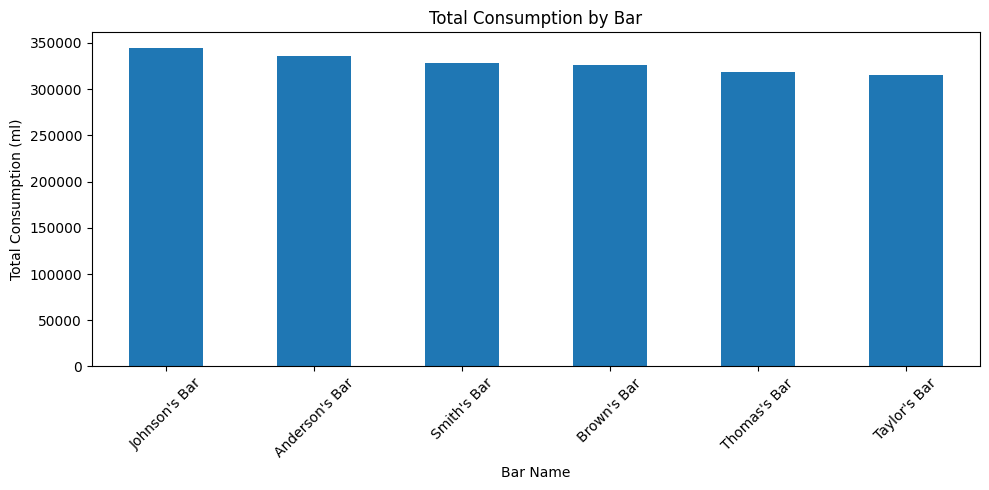

In [236]:
plt.figure(figsize=(10, 5))

bar_demand.plot(kind="bar")

plt.title("Total Consumption by Bar")
plt.xlabel("Bar Name")
plt.ylabel("Total Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [237]:
df["Historical_Stockout"] = (
    (df["Closing Balance (ml)"] == 0) &
    (df["Consumed (ml)"] > 0)
)

historical_stockouts = df["Historical_Stockout"].sum()

print("Historical stockout records:", historical_stockouts)
print(
    "Historical stockout percentage:",
    round(historical_stockouts / len(df) * 100, 2),
    "%"
)

Historical stockout records: 102
Historical stockout percentage: 1.55 %


## Historical Stockout Audit

Historical stockouts were identified using the rule:

**Closing Balance = 0 AND Consumption > 0**

This provides an audit of records where inventory reached zero despite recorded consumption.

Historical stockouts are distinguished from the later simulation results. The simulation estimates stockout exposure under the proposed inventory policy, while this audit describes the historical inventory records.

### Observation

Total alcohol consumption is relatively balanced across all six bars.

Johnson's Bar recorded the highest overall consumption, while Taylor's Bar recorded the lowest. However, the difference is not very large, suggesting that inventory optimization should focus more on individual brand demand rather than only bar-level demand.

## Demand Analysis


In [238]:
# Total consumption by brand

brand_demand = (
    daily_ts
    .groupby("Brand Name")["Consumption"]
    .sum()
    .sort_values(ascending=False)
)

print("========== TOTAL CONSUMPTION BY BRAND ==========")

display(brand_demand)

========== TOTAL CONSUMPTION BY BRAND ==========


,Consumption
Brand Name,
Grey Goose,158924.02
Jim Beam,139702.43
Captain Morgan,138035.53
Barefoot,132312.95
Yellow Tail,129843.65
Smirnoff,129176.67
Bacardi,127951.80
Malibu,127279.51
Jack Daniels,125050.89


### Insight

Brand-level consumption varies across the dataset. Grey Goose has the highest total consumption at 158,924.02 ml, while Budweiser has the lowest at 96,812.65 ml.

This variation indicates that inventory policies should be determined at the bar-brand level rather than using a single par level across all products.

High-consumption brands require closer monitoring and potentially higher safety stock, while slower-moving brands may require lower inventory levels to reduce overstocking.

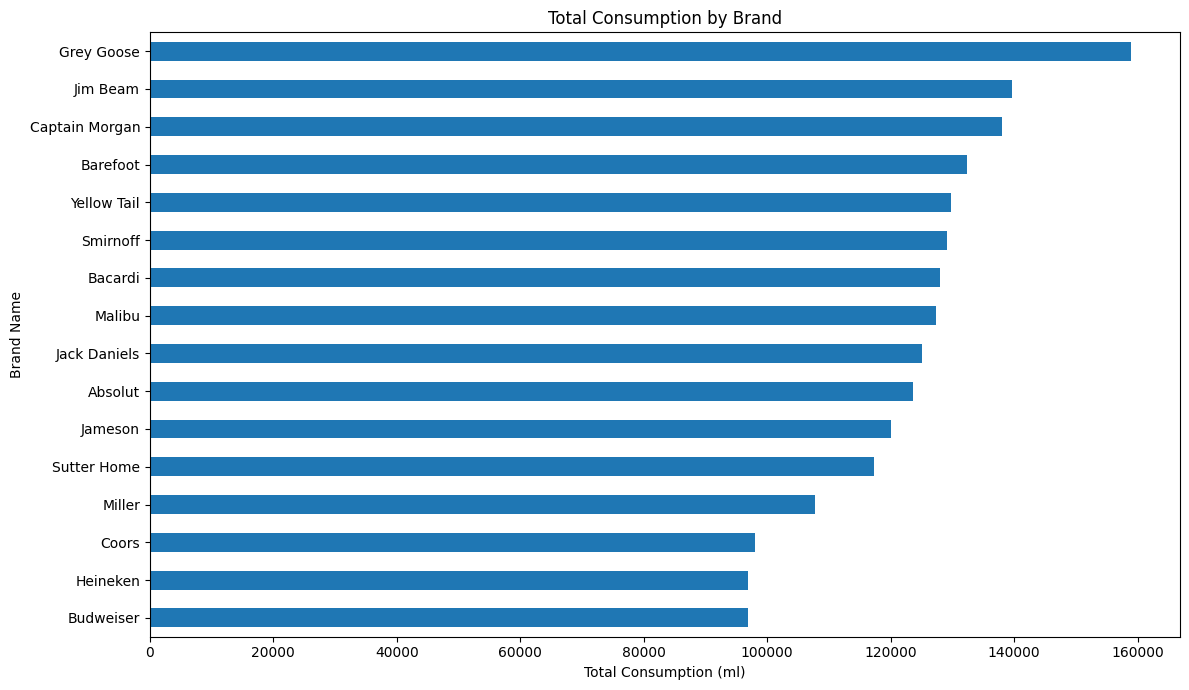

In [239]:
plt.figure(figsize=(12, 7))

brand_demand.sort_values().plot(kind="barh")

plt.title("Total Consumption by Brand")
plt.xlabel("Total Consumption (ml)")
plt.ylabel("Brand Name")
plt.tight_layout()
plt.show()

In [240]:
# ABC analysis based on total brand consumption

abc = brand_demand.reset_index()
abc.columns = ["Brand Name", "Total Consumption"]

# Sort from highest to lowest consumption
abc = abc.sort_values(
    "Total Consumption",
    ascending=False
).reset_index(drop=True)

# Calculate percentage contribution
abc["Consumption %"] = (
    abc["Total Consumption"]
    / abc["Total Consumption"].sum()
) * 100

# Calculate cumulative percentage
abc["Cumulative %"] = abc["Consumption %"].cumsum()

# Assign ABC category
def assign_abc(cumulative):
    if cumulative <= 70:
        return "A"
    elif cumulative <= 90:
        return "B"
    else:
        return "C"

abc["ABC Category"] = abc["Cumulative %"].apply(assign_abc)

display(abc)

,Brand Name,Total Consumption,Consumption %,Cumulative %,ABC Category
0,Grey Goose,158924.02,8.072611,8.072611,A
1,Jim Beam,139702.43,7.096243,15.168854,A
2,Captain Morgan,138035.53,7.011572,22.180426,A
3,Barefoot,132312.95,6.720891,28.901317,A
4,Yellow Tail,129843.65,6.595462,35.496779,A
5,Smirnoff,129176.67,6.561582,42.058362,A
6,Bacardi,127951.80,6.499365,48.557726,A
7,Malibu,127279.51,6.465215,55.022942,A
8,Jack Daniels,125050.89,6.352012,61.374953,A
9,Absolut,123659.02,6.281311,67.656264,A


### ABC Analysis Insight

The ABC analysis shows that the first 10 brands account for approximately 67.66% of total consumption and are classified as Category A.

Three brands fall into Category B, taking cumulative consumption to approximately 85.18%. The remaining three brands are classified as Category C.

This classification can support differentiated inventory policies. Category A items should receive closer monitoring and more frequent replenishment decisions because they contribute the largest share of consumption. Category B items can use moderate inventory controls, while Category C items can use simpler replenishment policies.

ABC classification is used as a prioritization mechanism and is combined with item-level demand forecasting and safety-stock calculations rather than being used alone to determine inventory levels.

In [241]:
zero_demand = (daily_ts["Consumption"] == 0).sum()
nonzero_demand = (daily_ts["Consumption"] > 0).sum()

total_records = len(daily_ts)

zero_pct = (zero_demand / total_records) * 100
nonzero_pct = (nonzero_demand / total_records) * 100

print("========== DEMAND INTERMITTENCY ==========")
print(f"Total daily records      : {total_records:,}")
print(f"Zero-demand records      : {zero_demand:,}")
print(f"Non-zero demand records  : {nonzero_demand:,}")
print(f"Zero-demand percentage   : {zero_pct:.2f}%")
print(f"Non-zero demand percentage: {nonzero_pct:.2f}%")

========== DEMAND INTERMITTENCY ==========
Total daily records      : 34,294
Zero-demand records      : 28,629
Non-zero demand records  : 5,665
Zero-demand percentage   : 83.48%
Non-zero demand percentage: 16.52%


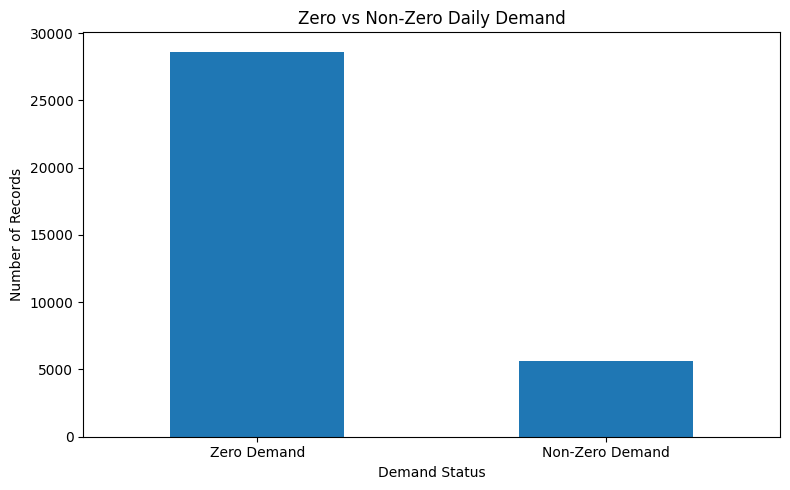

In [242]:
demand_status = pd.Series({
    "Zero Demand": zero_demand,
    "Non-Zero Demand": nonzero_demand
})

plt.figure(figsize=(8, 5))

demand_status.plot(kind="bar")

plt.title("Zero vs Non-Zero Daily Demand")
plt.xlabel("Demand Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Demand Intermittency Insight

The dataset contains a high proportion of zero-consumption daily records. Approximately 83.48% of the bar-brand-day records have zero recorded consumption, while approximately 16.52% have non-zero consumption.

This indicates intermittent demand, where consumption occurs irregularly rather than consistently every day.

Therefore, forecasting performance should be evaluated carefully, and the inventory policy should account for both demand magnitude and demand variability.

In [243]:
daily_ts["DayOfWeek"] = daily_ts["Date"].dt.day_name()

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand = (
    daily_ts
    .groupby("DayOfWeek")["Consumption"]
    .mean()
    .reindex(day_order)
)

print("========== AVERAGE CONSUMPTION BY DAY OF WEEK ==========")

display(weekday_demand)

========== AVERAGE CONSUMPTION BY DAY OF WEEK ==========


,Consumption
DayOfWeek,
Monday,55.199234
Tuesday,57.104176
Wednesday,59.625864
Thursday,56.699914
Friday,57.904938
Saturday,57.582208
Sunday,57.729318


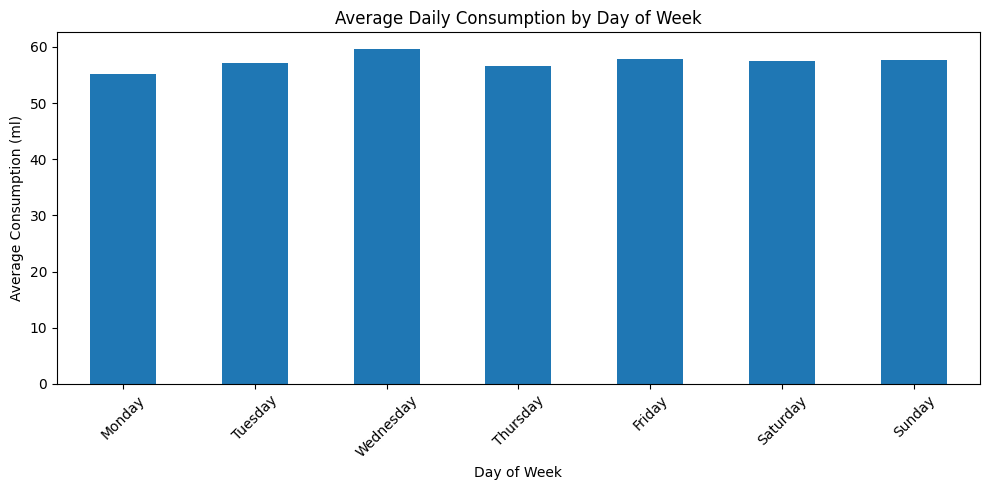

In [244]:
plt.figure(figsize=(10, 5))

weekday_demand.plot(kind="bar")

plt.title("Average Daily Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Day-of-Week Demand Insight

Average consumption is relatively consistent across the days of the week, ranging from approximately 55.20 ml on Monday to 59.63 ml on Wednesday.

Wednesday has the highest average consumption, while Monday has the lowest. The relatively small variation suggests that day-of-week seasonality exists but is not extremely strong in the overall dataset.

Therefore, day-of-week information can be included as a forecasting feature, but inventory recommendations should continue to rely primarily on item-level historical demand and variability.

In [245]:
# Create forecasting features

forecast_df = daily_ts.copy()

# Sort to ensure correct time order
forecast_df = forecast_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

# Create lag features for each bar-brand combination
group_cols = ["Bar Name", "Brand Name"]

forecast_df["Lag_1"] = (
    forecast_df.groupby(group_cols)["Consumption"]
    .shift(1)
)

forecast_df["Lag_7"] = (
    forecast_df.groupby(group_cols)["Consumption"]
    .shift(7)
)

forecast_df["Lag_14"] = (
    forecast_df.groupby(group_cols)["Consumption"]
    .shift(14)
)

# Rolling features based only on previous observations
forecast_df["Rolling_Mean_7"] = (
    forecast_df.groupby(group_cols)["Consumption"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)

forecast_df["Rolling_Std_7"] = (
    forecast_df.groupby(group_cols)["Consumption"]
    .transform(lambda x: x.shift(1).rolling(7).std())
)

# Calendar features
forecast_df["DayOfWeek_Num"] = forecast_df["Date"].dt.dayofweek

forecast_df["IsWeekend"] = (
    forecast_df["Date"].dt.dayofweek.isin([5, 6])
    .astype(int)
)

print("Forecasting dataset shape:", forecast_df.shape)

display(forecast_df.head(20))

Forecasting dataset shape: (34294, 12)


,Date,Bar Name,Brand Name,Consumption,DayOfWeek,Lag_1,Lag_7,Lag_14,Rolling_Mean_7,Rolling_Std_7,DayOfWeek_Num,IsWeekend
0,2023-01-02,Anderson's Bar,Absolut,118.62,Monday,NaN,NaN,NaN,NaN,NaN,0,0
1,2023-01-03,Anderson's Bar,Absolut,0.00,Tuesday,118.62,NaN,NaN,NaN,NaN,1,0
2,2023-01-04,Anderson's Bar,Absolut,0.00,Wednesday,0.00,NaN,NaN,NaN,NaN,2,0
3,2023-01-05,Anderson's Bar,Absolut,463.20,Thursday,0.00,NaN,NaN,NaN,NaN,3,0
4,2023-01-06,Anderson's Bar,Absolut,453.02,Friday,463.20,NaN,NaN,NaN,NaN,4,0
5,2023-01-07,Anderson's Bar,Absolut,0.00,Saturday,453.02,NaN,NaN,NaN,NaN,5,1
6,2023-01-08,Anderson's Bar,Absolut,275.08,Sunday,0.00,NaN,NaN,NaN,NaN,6,1
7,2023-01-09,Anderson's Bar,Absolut,0.00,Monday,275.08,118.62,NaN,187.131429,209.918187,0,0
8,2023-01-10,Anderson's Bar,Absolut,0.00,Tuesday,0.00,0.00,NaN,170.185714,220.872560,1,0
9,2023-01-11,Anderson's Bar,Absolut,0.00,Wednesday,0.00,0.00,NaN,170.185714,220.872560,2,0


In [246]:
model_df = forecast_df.dropna(
    subset=[
        "Lag_1",
        "Lag_7",
        "Lag_14",
        "Rolling_Mean_7",
        "Rolling_Std_7"
    ]
).copy()

print("Original forecasting dataset:", forecast_df.shape)
print("Model-ready dataset:", model_df.shape)

print("\nMissing values in model features:")
display(
    model_df[
        [
            "Lag_1",
            "Lag_7",
            "Lag_14",
            "Rolling_Mean_7",
            "Rolling_Std_7"
        ]
    ].isnull().sum()
)

Original forecasting dataset: (34294, 12)
Model-ready dataset: (32950, 12)

Missing values in model features:


,0
Lag_1,0
Lag_7,0
Lag_14,0
Rolling_Mean_7,0
Rolling_Std_7,0


In [247]:
print("Modeling period:")
print("Start date:", model_df["Date"].min())
print("End date  :", model_df["Date"].max())

Modeling period:
Start date: 2023-01-15 00:00:00
End date  : 2024-01-01 00:00:00


In [248]:
unique_dates = sorted(model_df["Date"].unique())

split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index - 1]
test_start_date = unique_dates[split_index]

train_df = model_df[
    model_df["Date"] <= train_end_date
].copy()

test_df = model_df[
    model_df["Date"] >= test_start_date
].copy()

print("========== TEMPORAL TRAIN/TEST SPLIT ==========")
print("Training period:")
print(train_df["Date"].min(), "to", train_df["Date"].max())

print("\nTesting period:")
print(test_df["Date"].min(), "to", test_df["Date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows :", len(test_df))

========== TEMPORAL TRAIN/TEST SPLIT ==========
Training period:
2023-01-15 00:00:00 to 2023-10-22 00:00:00

Testing period:
2023-10-23 00:00:00 to 2024-01-01 00:00:00

Training rows: 26609
Testing rows : 6341


In [249]:
# Step 27: Temporal Train-Test Split

# Get all unique dates in chronological order
unique_dates = sorted(model_df["Date"].unique())

# Use the first 80% of dates for training
split_index = int(len(unique_dates) * 0.80)

train_end_date = unique_dates[split_index - 1]
test_start_date = unique_dates[split_index]

# Create train and test datasets
train_df = model_df[
    model_df["Date"] <= train_end_date
].copy()

test_df = model_df[
    model_df["Date"] >= test_start_date
].copy()

print("Training period:")
print("Start:", train_df["Date"].min())
print("End:", train_df["Date"].max())

print("\nTesting period:")
print("Start:", test_df["Date"].min())
print("End:", test_df["Date"].max())

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTrain/Test ratio:")
print(f"{len(train_df) / len(model_df) * 100:.2f}% / "
      f"{len(test_df) / len(model_df) * 100:.2f}%")

Training period:
Start: 2023-01-15 00:00:00
End: 2023-10-22 00:00:00

Testing period:
Start: 2023-10-23 00:00:00
End: 2024-01-01 00:00:00

Training rows: 26609
Testing rows: 6341

Train/Test ratio:
80.76% / 19.24%


In [250]:
# Step 28: Baseline Forecast
# Use the previous 7-day average as the baseline prediction

test_df["Baseline_Forecast"] = test_df["Rolling_Mean_7"]

print("Baseline forecast created.")

display(
    test_df[
        [
            "Date",
            "Bar Name",
            "Brand Name",
            "Consumption",
            "Baseline_Forecast"
        ]
    ].head(10)
)

Baseline forecast created.


,Date,Bar Name,Brand Name,Consumption,Baseline_Forecast
294,2023-10-23,Anderson's Bar,Absolut,0.00,71.728571
295,2023-10-24,Anderson's Bar,Absolut,174.39,71.728571
296,2023-10-25,Anderson's Bar,Absolut,0.00,96.641429
297,2023-10-26,Anderson's Bar,Absolut,0.00,96.641429
298,2023-10-27,Anderson's Bar,Absolut,0.00,24.912857
299,2023-10-28,Anderson's Bar,Absolut,0.00,24.912857
300,2023-10-29,Anderson's Bar,Absolut,0.00,24.912857
301,2023-10-30,Anderson's Bar,Absolut,0.00,24.912857
302,2023-10-31,Anderson's Bar,Absolut,401.81,24.912857
303,2023-11-01,Anderson's Bar,Absolut,0.00,57.401429


In [251]:
# Evaluate Baseline Model using MAE

from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    test_df["Consumption"],
    test_df["Baseline_Forecast"]
)

print(f"Baseline MAE: {baseline_mae:.2f} ml")

Baseline MAE: 95.83 ml


In [252]:
# Step 29: Exponential Smoothing Forecast

from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np

# Store predictions
statistical_predictions = []

# Forecast each Bar + Brand combination separately
for (bar, brand), group in train_df.groupby(["Bar Name", "Brand Name"]):

    group = group.sort_values("Date")

    # Training demand series
    y_train = group["Consumption"].values

    # Need enough observations for the model
    if len(y_train) < 14:
        continue

    try:
        model = ExponentialSmoothing(
            y_train,
            trend=None,
            seasonal=None,
            initialization_method="estimated"
        )

        fitted_model = model.fit(optimized=True)

        # Find corresponding test records
        group_test = test_df[
            (test_df["Bar Name"] == bar) &
            (test_df["Brand Name"] == brand)
        ].sort_values("Date")

        if len(group_test) == 0:
            continue

        forecast = fitted_model.forecast(len(group_test))

        for date, prediction in zip(
            group_test["Date"],
            forecast
        ):
            statistical_predictions.append({
                "Date": date,
                "Bar Name": bar,
                "Brand Name": brand,
                "Statistical_Forecast": max(0, prediction)
            })

    except Exception:
        continue

# Convert predictions to DataFrame
statistical_predictions_df = pd.DataFrame(
    statistical_predictions
)

print(
    "Statistical forecast rows:",
    len(statistical_predictions_df)
)

display(statistical_predictions_df.head())

Statistical forecast rows: 6341


,Date,Bar Name,Brand Name,Statistical_Forecast
0,2023-10-23,Anderson's Bar,Absolut,28.909036
1,2023-10-24,Anderson's Bar,Absolut,28.909036
2,2023-10-25,Anderson's Bar,Absolut,28.909036
3,2023-10-26,Anderson's Bar,Absolut,28.909036
4,2023-10-27,Anderson's Bar,Absolut,28.909036


In [253]:
# Step 30: Evaluate Exponential Smoothing Model

# Merge statistical forecasts with actual test demand
evaluation_df = test_df[
    [
        "Date",
        "Bar Name",
        "Brand Name",
        "Consumption"
    ]
].merge(
    statistical_predictions_df,
    on=["Date", "Bar Name", "Brand Name"],
    how="inner"
)

# Calculate MAE
statistical_mae = mean_absolute_error(
    evaluation_df["Consumption"],
    evaluation_df["Statistical_Forecast"]
)

print(f"Baseline MAE: {baseline_mae:.2f} ml")
print(f"Statistical Model MAE: {statistical_mae:.2f} ml")

# Compare improvement
improvement = (
    (baseline_mae - statistical_mae)
    / baseline_mae
) * 100

print(f"Improvement over baseline: {improvement:.2f}%")

Baseline MAE: 95.83 ml
Statistical Model MAE: 95.52 ml
Improvement over baseline: 0.33%


In [254]:
# Step 31: Random Forest Demand Forecasting

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# Features used for forecasting
features = [
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_7",
    "Rolling_Std_7",
    "DayOfWeek_Num",
    "IsWeekend"
]

X_train = train_df[features]
y_train = train_df["Consumption"]

X_test = test_df[features]
y_test = test_df["Consumption"]

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Generate predictions
rf_predictions = rf_model.predict(X_test)

# Demand cannot be negative
rf_predictions = np.maximum(rf_predictions, 0)

# Evaluate
rf_mae = mean_absolute_error(y_test, rf_predictions)

print(f"Random Forest MAE: {rf_mae:.2f} ml")

# Compare with baseline
rf_improvement = (
    (baseline_mae - rf_mae) / baseline_mae
) * 100

print(f"Improvement over baseline: {rf_improvement:.2f}%")

Random Forest MAE: 96.32 ml
Improvement over baseline: -0.51%


In [255]:
# Step 32: Compare Models Using WAPE

def calculate_wape(actual, predicted):
    return (
        np.abs(actual - predicted).sum()
        / np.abs(actual).sum()
    ) * 100


# Baseline WAPE
baseline_wape = calculate_wape(
    test_df["Consumption"],
    test_df["Baseline_Forecast"]
)

# Statistical model WAPE
statistical_wape = calculate_wape(
    evaluation_df["Consumption"],
    evaluation_df["Statistical_Forecast"]
)

# Random Forest WAPE
rf_wape = calculate_wape(
    y_test,
    rf_predictions
)


print(f"Baseline WAPE: {baseline_wape:.2f}%")
print(f"Exponential Smoothing WAPE: {statistical_wape:.2f}%")
print(f"Random Forest WAPE: {rf_wape:.2f}%")

Baseline WAPE: 160.21%
Exponential Smoothing WAPE: 159.68%
Random Forest WAPE: 161.02%


In [256]:
# Step 33: Final Model Comparison

model_comparison = pd.DataFrame({
    "Model": [
        "7-Day Rolling Mean Baseline",
        "Exponential Smoothing",
        "Random Forest"
    ],
    "MAE (ml)": [
        baseline_mae,
        statistical_mae,
        rf_mae
    ],
    "WAPE (%)": [
        baseline_wape,
        statistical_wape,
        rf_wape
    ]
})

display(model_comparison.round(2))

,Model,MAE (ml),WAPE (%)
0,7-Day Rolling Mean Baseline,95.83,160.21
1,Exponential Smoothing,95.52,159.68
2,Random Forest,96.32,161.02


## Model Selection

Three forecasting approaches were evaluated using a time-based test set:

1. 7-day rolling mean baseline
2. Exponential Smoothing
3. Random Forest regression

Exponential Smoothing produced the lowest MAE (95.52 ml) and WAPE (159.68%) among the tested approaches. However, the improvement over the rolling-mean baseline was small (0.33%), indicating that the highly intermittent nature of demand limits the benefit of these forecasting approaches.

For the inventory policy and simulation, Exponential Smoothing forecasts are used because they achieved the lowest error among the tested models.

The high WAPE should be interpreted carefully because 83.48% of the daily bar-brand observations have zero consumption. In production, additional information such as POS transactions, opening hours, events, promotions, and stockout indicators could improve demand forecasting.

In [257]:
# Step 34: Inventory Policy Parameters

import numpy as np

LEAD_TIME_DAYS = 2
SERVICE_LEVEL = 0.95
Z_SCORE = 1.645

print(f"Lead time: {LEAD_TIME_DAYS} days")
print(f"Target service level: {SERVICE_LEVEL:.0%}")
print(f"Z-score: {Z_SCORE}")

Lead time: 2 days
Target service level: 95%
Z-score: 1.645


In [258]:
demand_stats = (
    train_df.groupby(["Bar Name", "Brand Name"])
    .agg(
        Average_Demand=("Consumption", "mean"),
        Demand_Std=("Consumption", "std")
    )
    .reset_index()
)

# Calculate average forecast from Exponential Smoothing
forecast_stats = (
    statistical_predictions_df
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        Forecast_Daily_Demand=("Statistical_Forecast", "mean")
    )
    .reset_index()
)

# Combine demand statistics and forecasts
inventory_policy = demand_stats.merge(
    forecast_stats,
    on=["Bar Name", "Brand Name"],
    how="inner"
)

# Calculate safety stock
inventory_policy["Safety_Stock"] = (
    Z_SCORE
    * inventory_policy["Demand_Std"]
    * np.sqrt(LEAD_TIME_DAYS)
)

# Calculate lead-time demand
inventory_policy["Lead_Time_Demand"] = (
    inventory_policy["Forecast_Daily_Demand"]
    * LEAD_TIME_DAYS
)

# Calculate recommended par level
inventory_policy["Recommended_Par_Level"] = (
    inventory_policy["Lead_Time_Demand"]
    + inventory_policy["Safety_Stock"]
)

# Ensure no negative values
inventory_policy["Recommended_Par_Level"] = (
    inventory_policy["Recommended_Par_Level"].clip(lower=0)
)

# Display results
display(
    inventory_policy[
        [
            "Bar Name",
            "Brand Name",
            "Average_Demand",
            "Forecast_Daily_Demand",
            "Demand_Std",
            "Safety_Stock",
            "Lead_Time_Demand",
            "Recommended_Par_Level"
        ]
    ].round(2).head(20)
)

,Bar Name,Brand Name,Average_Demand,Forecast_Daily_Demand,Demand_Std,Safety_Stock,Lead_Time_Demand,Recommended_Par_Level
0,Anderson's Bar,Absolut,28.91,28.91,92.97,216.29,57.82,274.11
1,Anderson's Bar,Bacardi,74.89,74.89,163.54,380.46,149.78,530.24
2,Anderson's Bar,Barefoot,79.75,79.75,167.03,388.58,159.50,548.08
3,Anderson's Bar,Budweiser,34.29,34.29,111.67,259.79,68.58,328.38
4,Anderson's Bar,Captain Morgan,73.49,73.49,171.85,399.78,146.99,546.77
5,Anderson's Bar,Coors,58.21,58.21,145.11,337.59,116.41,454.00
6,Anderson's Bar,Grey Goose,66.41,66.41,152.05,353.74,132.82,486.56
7,Anderson's Bar,Heineken,50.90,38.63,139.16,323.74,77.26,401.00
8,Anderson's Bar,Jack Daniels,55.58,55.58,135.64,315.55,111.17,426.71
9,Anderson's Bar,Jameson,63.05,63.05,153.85,357.91,126.09,484.01


In [259]:
# Step 36: Inventory Simulation

# Merge recommended par levels with test-period demand
simulation_df = test_df[
    ["Date", "Bar Name", "Brand Name", "Consumption"]
].merge(
    inventory_policy[
        ["Bar Name", "Brand Name", "Recommended_Par_Level"]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

# Sort chronologically
simulation_df = simulation_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

# Store simulation results
simulation_results = []

# Simulate each Bar + Brand independently
for (bar, brand), group in simulation_df.groupby(
    ["Bar Name", "Brand Name"]
):

    group = group.sort_values("Date").copy()

    par_level = group["Recommended_Par_Level"].iloc[0]

    # Start with inventory equal to the par level
    inventory = par_level

    for _, row in group.iterrows():

        demand = row["Consumption"]

        # Inventory available before demand
        beginning_inventory = inventory

        # Actual demand fulfilled
        fulfilled_demand = min(inventory, demand)

        # Lost sales / stockout quantity
        stockout_quantity = max(0, demand - inventory)

        # Inventory after demand
        ending_inventory = max(0, inventory - demand)

        # Replenishment to restore inventory to par level
        replenishment = max(0, par_level - ending_inventory)

        # Apply replenishment for the next day
        inventory = ending_inventory + replenishment

        simulation_results.append({
            "Date": row["Date"],
            "Bar Name": bar,
            "Brand Name": brand,
            "Demand": demand,
            "Beginning_Inventory": beginning_inventory,
            "Fulfilled_Demand": fulfilled_demand,
            "Stockout_Quantity": stockout_quantity,
            "Ending_Inventory": ending_inventory,
            "Replenishment": replenishment,
            "Par_Level": par_level
        })

# Convert to DataFrame
simulation_results_df = pd.DataFrame(simulation_results)

print("Simulation rows:", len(simulation_results_df))

display(simulation_results_df.head(20))

Simulation rows: 6341


,Date,Bar Name,Brand Name,Demand,Beginning_Inventory,Fulfilled_Demand,Stockout_Quantity,Ending_Inventory,Replenishment,Par_Level
0,2023-10-23,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
1,2023-10-24,Anderson's Bar,Absolut,174.39,274.110466,174.390000,0.000000,99.720466,174.390000,274.110466
2,2023-10-25,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
3,2023-10-26,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
4,2023-10-27,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
5,2023-10-28,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
6,2023-10-29,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
7,2023-10-30,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466
8,2023-10-31,Anderson's Bar,Absolut,401.81,274.110466,274.110466,127.699534,0.000000,274.110466,274.110466
9,2023-11-01,Anderson's Bar,Absolut,0.00,274.110466,0.000000,0.000000,274.110466,0.000000,274.110466


In [260]:
# Step 37: Calculate Inventory Simulation Metrics

total_demand = simulation_results_df["Demand"].sum()
total_fulfilled = simulation_results_df["Fulfilled_Demand"].sum()
total_stockout = simulation_results_df["Stockout_Quantity"].sum()

# Fill rate
fill_rate = (
    total_fulfilled / total_demand
) * 100

# Stockout rate
stockout_rate = (
    total_stockout / total_demand
) * 100

# Number of days with stockouts
stockout_days = (
    simulation_results_df["Stockout_Quantity"] > 0
).sum()

# Total simulated days
total_simulation_days = len(simulation_results_df)

# Average inventory
average_inventory = (
    simulation_results_df["Ending_Inventory"].mean()
)

print(f"Total demand: {total_demand:.2f} ml")
print(f"Total fulfilled demand: {total_fulfilled:.2f} ml")
print(f"Total stockout quantity: {total_stockout:.2f} ml")
print(f"Fill rate: {fill_rate:.2f}%")
print(f"Stockout rate: {stockout_rate:.2f}%")
print(f"Stockout records: {stockout_days}")
print(f"Total simulation records: {total_simulation_days}")
print(f"Average ending inventory: {average_inventory:.2f} ml")

Total demand: 379309.96 ml
Total fulfilled demand: 341123.93 ml
Total stockout quantity: 38186.03 ml
Fill rate: 89.93%
Stockout rate: 10.07%
Stockout records: 347
Total simulation records: 6341
Average ending inventory: 384.99 ml


In [261]:
# Step 38: Inventory Policy Sensitivity Analysis

service_levels = {
    0.90: 1.282,
    0.95: 1.645,
    0.99: 2.326
}

lead_times = [1, 2, 3]

sensitivity_results = []

# Calculate demand statistics once
demand_stats_sensitivity = (
    train_df.groupby(["Bar Name", "Brand Name"])
    .agg(
        Demand_Std=("Consumption", "std")
    )
    .reset_index()
)

# Average forecast per Bar + Brand
forecast_stats_sensitivity = (
    statistical_predictions_df
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        Forecast_Daily_Demand=("Statistical_Forecast", "mean")
    )
    .reset_index()
)

policy_base = demand_stats_sensitivity.merge(
    forecast_stats_sensitivity,
    on=["Bar Name", "Brand Name"],
    how="inner"
)

for service_level, z_score in service_levels.items():

    for lead_time in lead_times:

        policy_temp = policy_base.copy()

        # Safety stock
        policy_temp["Safety_Stock"] = (
            z_score
            * policy_temp["Demand_Std"]
            * np.sqrt(lead_time)
        )

        # Lead-time demand
        policy_temp["Lead_Time_Demand"] = (
            policy_temp["Forecast_Daily_Demand"]
            * lead_time
        )

        # Par level
        policy_temp["Recommended_Par_Level"] = (
            policy_temp["Lead_Time_Demand"]
            + policy_temp["Safety_Stock"]
        )

        # Average par level across all Bar + Brand combinations
        average_par = policy_temp["Recommended_Par_Level"].mean()

        sensitivity_results.append({
            "Service_Level": service_level,
            "Lead_Time_Days": lead_time,
            "Average_Par_Level_ml": average_par
        })

sensitivity_df = pd.DataFrame(sensitivity_results)

display(
    sensitivity_df.round(2)
)

,Service_Level,Lead_Time_Days,Average_Par_Level_ml
0,0.90,1,235.88
1,0.90,2,365.68
2,0.90,3,478.04
3,0.95,1,287.15
4,0.95,2,438.19
5,0.95,3,566.85
6,0.99,1,383.34
7,0.99,2,574.23
8,0.99,3,733.45


## Sensitivity Analysis

The sensitivity analysis evaluates how inventory requirements change under different service levels and supplier lead times.

The results show that recommended par levels increase as either the target service level or lead time increases. This is expected because higher service levels require additional safety stock, while longer lead times require inventory to cover a longer period of expected demand.

Under the selected baseline assumption of a 95% service level and 2-day lead time, the average recommended par level is 438.19 ml across the analyzed Bar + Brand combinations.

This analysis helps hotel operations understand the inventory trade-off between service reliability and inventory holding requirements.

In [262]:
# Step 39: Correct Inventory Simulation with Lead Time

simulation_df = test_df[
    ["Date", "Bar Name", "Brand Name", "Consumption"]
].merge(
    inventory_policy[
        ["Bar Name", "Brand Name", "Recommended_Par_Level"]
    ],
    on=["Bar Name", "Brand Name"],
    how="left"
)

simulation_df = simulation_df.sort_values(
    ["Bar Name", "Brand Name", "Date"]
).reset_index(drop=True)

simulation_results = []

for (bar, brand), group in simulation_df.groupby(
    ["Bar Name", "Brand Name"]
):

    group = group.sort_values("Date").copy()

    par_level = group["Recommended_Par_Level"].iloc[0]

    # Start with inventory equal to the recommended par level
    inventory = par_level

    # Orders already placed but not yet received
    pending_orders = [0] * LEAD_TIME_DAYS

    for _, row in group.iterrows():

        # Receive any order whose lead time has completed
        arrival = pending_orders.pop(0)
        inventory += arrival

        demand = row["Consumption"]

        beginning_inventory = inventory

        # Fulfill as much demand as possible
        fulfilled_demand = min(inventory, demand)

        # Remaining unmet demand
        stockout_quantity = max(0, demand - inventory)

        # Inventory after demand
        ending_inventory = max(0, inventory - demand)

        # Inventory position = on-hand inventory + outstanding orders
        inventory_position = (
            ending_inventory + sum(pending_orders)
        )

        # Order enough to restore inventory position to par
        order_quantity = max(
            0,
            par_level - inventory_position
        )

        # Order arrives after the specified lead time
        pending_orders.append(order_quantity)

        inventory = ending_inventory

        simulation_results.append({
            "Date": row["Date"],
            "Bar Name": bar,
            "Brand Name": brand,
            "Demand": demand,
            "Beginning_Inventory": beginning_inventory,
            "Arrival": arrival,
            "Fulfilled_Demand": fulfilled_demand,
            "Stockout_Quantity": stockout_quantity,
            "Ending_Inventory": ending_inventory,
            "Order_Placed": order_quantity,
            "Inventory_Position": inventory_position,
            "Par_Level": par_level
        })

simulation_results_lead_time_df = pd.DataFrame(
    simulation_results
)

print(
    "Simulation rows:",
    len(simulation_results_lead_time_df)
)

display(
    simulation_results_lead_time_df.head(20).round(2)
)

Simulation rows: 6341


,Date,Bar Name,Brand Name,Demand,Beginning_Inventory,Arrival,Fulfilled_Demand,Stockout_Quantity,Ending_Inventory,Order_Placed,Inventory_Position,Par_Level
0,2023-10-23,Anderson's Bar,Absolut,0.00,274.11,0.00,0.00,0.00,274.11,0.00,274.11,274.11
1,2023-10-24,Anderson's Bar,Absolut,174.39,274.11,0.00,174.39,0.00,99.72,174.39,99.72,274.11
2,2023-10-25,Anderson's Bar,Absolut,0.00,99.72,0.00,0.00,0.00,99.72,0.00,274.11,274.11
3,2023-10-26,Anderson's Bar,Absolut,0.00,274.11,174.39,0.00,0.00,274.11,0.00,274.11,274.11
4,2023-10-27,Anderson's Bar,Absolut,0.00,274.11,0.00,0.00,0.00,274.11,0.00,274.11,274.11
5,2023-10-28,Anderson's Bar,Absolut,0.00,274.11,0.00,0.00,0.00,274.11,0.00,274.11,274.11
6,2023-10-29,Anderson's Bar,Absolut,0.00,274.11,0.00,0.00,0.00,274.11,0.00,274.11,274.11
7,2023-10-30,Anderson's Bar,Absolut,0.00,274.11,0.00,0.00,0.00,274.11,0.00,274.11,274.11
8,2023-10-31,Anderson's Bar,Absolut,401.81,274.11,0.00,274.11,127.70,0.00,274.11,0.00,274.11
9,2023-11-01,Anderson's Bar,Absolut,0.00,0.00,0.00,0.00,0.00,0.00,0.00,274.11,274.11


In [263]:
# Step 40: Final Inventory Simulation Metrics

total_demand = simulation_results_lead_time_df["Demand"].sum()

total_fulfilled_demand = (
    simulation_results_lead_time_df["Fulfilled_Demand"].sum()
)

total_stockout_quantity = (
    simulation_results_lead_time_df["Stockout_Quantity"].sum()
)

fill_rate = (
    total_fulfilled_demand / total_demand
) * 100

stockout_rate = (
    total_stockout_quantity / total_demand
) * 100

stockout_records = (
    simulation_results_lead_time_df["Stockout_Quantity"] > 0
).sum()

total_records = len(simulation_results_lead_time_df)

average_ending_inventory = (
    simulation_results_lead_time_df["Ending_Inventory"].mean()
)

total_orders = (
    simulation_results_lead_time_df["Order_Placed"].sum()
)

print("Final Inventory Simulation Metrics")
print("-" * 45)
print(f"Total demand: {total_demand:.2f} ml")
print(f"Total fulfilled demand: {total_fulfilled_demand:.2f} ml")
print(f"Total stockout quantity: {total_stockout_quantity:.2f} ml")
print(f"Fill rate: {fill_rate:.2f}%")
print(f"Stockout rate: {stockout_rate:.2f}%")
print(f"Stockout records: {stockout_records}")
print(f"Total simulation records: {total_records}")
print(f"Average ending inventory: {average_ending_inventory:.2f} ml")
print(f"Total replenishment quantity: {total_orders:.2f} ml")

Final Inventory Simulation Metrics
---------------------------------------------
Total demand: 379309.96 ml
Total fulfilled demand: 309542.49 ml
Total stockout quantity: 69767.47 ml
Fill rate: 81.61%
Stockout rate: 18.39%
Stockout records: 427
Total simulation records: 6341
Average ending inventory: 344.71 ml
Total replenishment quantity: 309542.49 ml


In [264]:
# Inventory Turnover Ratio

total_fulfilled = simulation_results_lead_time_df["Fulfilled_Demand"].sum()
average_inventory = simulation_results_lead_time_df["Ending_Inventory"].mean()

turnover_ratio = total_fulfilled / average_inventory

print("Inventory Turnover Ratio:", round(turnover_ratio, 2))

Inventory Turnover Ratio: 897.99


## Inventory Turnover Ratio

Inventory turnover is calculated as:

**Turnover Ratio = Total Fulfilled Demand / Average Inventory**

This provides an approximate measure of how efficiently inventory is being consumed during the simulation period.

In [265]:
# Step 41: Stockout Analysis by Bar and Brand

stockout_summary = (
    simulation_results_lead_time_df
    .groupby(["Bar Name", "Brand Name"])
    .agg(
        Total_Demand=("Demand", "sum"),
        Fulfilled_Demand=("Fulfilled_Demand", "sum"),
        Stockout_Quantity=("Stockout_Quantity", "sum"),
        Stockout_Records=(
            "Stockout_Quantity",
            lambda x: (x > 0).sum()
        ),
        Average_Inventory=("Ending_Inventory", "mean"),
        Par_Level=("Par_Level", "first")
    )
    .reset_index()
)

stockout_summary["Fill_Rate"] = (
    stockout_summary["Fulfilled_Demand"]
    / stockout_summary["Total_Demand"]
) * 100

stockout_summary["Stockout_Rate"] = (
    stockout_summary["Stockout_Quantity"]
    / stockout_summary["Total_Demand"]
) * 100

# Sort by total stockout quantity
stockout_summary = stockout_summary.sort_values(
    "Stockout_Quantity",
    ascending=False
).reset_index(drop=True)

display(
    stockout_summary.head(15).round(2)
)

,Bar Name,Brand Name,Total_Demand,Fulfilled_Demand,Stockout_Quantity,Stockout_Records,Average_Inventory,Par_Level,Fill_Rate,Stockout_Rate
0,Brown's Bar,Coors,4660.67,1964.98,2695.69,5,267.10,328.51,42.16,57.84
1,Thomas's Bar,Yellow Tail,7065.50,4591.65,2473.85,14,193.22,329.43,64.99,35.01
2,Taylor's Bar,Smirnoff,6983.46,4701.62,2281.84,12,223.36,354.50,67.33,32.67
3,Taylor's Bar,Jim Beam,6412.86,4268.02,2144.84,8,328.82,447.66,66.55,33.45
4,Johnson's Bar,Jim Beam,5240.77,3463.11,1777.66,10,266.93,365.69,66.08,33.92
5,Taylor's Bar,Sutter Home,4552.74,2783.01,1769.73,8,265.41,344.92,61.13,38.87
6,Brown's Bar,Grey Goose,6080.76,4404.96,1675.80,7,391.21,520.77,72.44,27.56
7,Taylor's Bar,Jameson,5029.53,3371.14,1658.39,9,318.80,424.15,67.03,32.97
8,Brown's Bar,Malibu,5517.11,3979.93,1537.18,7,292.21,403.45,72.14,27.86
9,Smith's Bar,Smirnoff,4610.47,3218.25,1392.22,9,240.86,337.66,69.80,30.20


In [266]:
# Step 42: Final Inventory Recommendations

final_recommendations = stockout_summary[
    [
        "Bar Name",
        "Brand Name",
        "Total_Demand",
        "Stockout_Quantity",
        "Stockout_Records",
        "Par_Level",
        "Fill_Rate",
        "Stockout_Rate"
    ]
].copy()

# Prioritize combinations with high stockout quantity
final_recommendations["Priority"] = "Monitor"

final_recommendations.loc[
    final_recommendations["Stockout_Quantity"]
    >= final_recommendations["Stockout_Quantity"].quantile(0.75),
    "Priority"
] = "High"

final_recommendations.loc[
    final_recommendations["Stockout_Quantity"]
    >= final_recommendations["Stockout_Quantity"].quantile(0.90),
    "Priority"
] = "Critical"

final_recommendations = final_recommendations.sort_values(
    ["Priority", "Stockout_Quantity"],
    ascending=[True, False]
)

display(
    final_recommendations.head(15).round(2)
)

,Bar Name,Brand Name,Total_Demand,Stockout_Quantity,Stockout_Records,Par_Level,Fill_Rate,Stockout_Rate,Priority
0,Brown's Bar,Coors,4660.67,2695.69,5,328.51,42.16,57.84,Critical
1,Thomas's Bar,Yellow Tail,7065.50,2473.85,14,329.43,64.99,35.01,Critical
2,Taylor's Bar,Smirnoff,6983.46,2281.84,12,354.50,67.33,32.67,Critical
3,Taylor's Bar,Jim Beam,6412.86,2144.84,8,447.66,66.55,33.45,Critical
4,Johnson's Bar,Jim Beam,5240.77,1777.66,10,365.69,66.08,33.92,Critical
5,Taylor's Bar,Sutter Home,4552.74,1769.73,8,344.92,61.13,38.87,Critical
6,Brown's Bar,Grey Goose,6080.76,1675.80,7,520.77,72.44,27.56,Critical
7,Taylor's Bar,Jameson,5029.53,1658.39,9,424.15,67.03,32.97,Critical
8,Brown's Bar,Malibu,5517.11,1537.18,7,403.45,72.14,27.86,Critical
9,Smith's Bar,Smirnoff,4610.47,1392.22,9,337.66,69.80,30.20,Critical


## Final Inventory Recommendations

The inventory simulation identifies specific Bar + Brand combinations where stockouts are concentrated.

The highest stockout quantities occur for combinations such as Brown's Bar–Coors, Thomas's Bar–Yellow Tail, Taylor's Bar–Smirnoff, and Taylor's Bar–Jim Beam.

These combinations should receive closer inventory monitoring because the simulation indicates relatively low fill rates and higher stockout quantities under the assumed 2-day lead time.

The recommended par level provides a baseline inventory target for each Bar + Brand combination. In practice, these recommendations should be reviewed using current sales activity, supplier lead times, upcoming events, promotions, operating hours, and actual stock availability before being used for purchasing decisions.

The priority labels are based on the simulated stockout-quantity distribution and are intended as an operational monitoring aid rather than a permanent business classification.

## Business Recommendations

Based on the demand forecasting, inventory policy, and simulation results, the following recommendations can support hotel bar inventory operations:

1. **Use Bar + Brand level forecasting**
   - Demand varies across individual bars and brands.
   - Forecasting at the Bar + Brand level provides more actionable inventory recommendations than using a single overall demand estimate.

2. **Use recommended par levels as replenishment targets**
   - The calculated par level combines expected lead-time demand with safety stock.
   - This provides an initial inventory target for each Bar + Brand combination.

3. **Monitor high stockout-exposure combinations**
   - The simulation identified combinations with relatively high stockout quantities and lower fill rates.
   - These combinations should receive closer monitoring and more frequent inventory review.

4. **Prioritize high-demand inventory**
   - ABC analysis can be used to focus operational attention on high-consumption brands.
   - A-category items represent the largest share of total consumption and therefore have greater inventory impact.

5. **Validate recommendations with operational data**
   - Before deploying the recommendations, the hotel should incorporate actual POS transactions, supplier lead times, stock availability, opening hours, promotions, events, and purchasing constraints.

6. **Review inventory policies regularly**
   - Demand patterns and supplier conditions can change over time.
   - Par levels should therefore be recalculated periodically using recent demand data.

### Important Operational Note

The simulation uses a 2-day lead-time assumption and a 95% target service level. The 95% value is an input to the safety-stock calculation; it does not mean that the simulation achieved a 95% fill rate.

Under the simulated historical test period, the resulting fill rate was 81.61%. This indicates that the current baseline inventory policy would require further refinement before production deployment.

## Assumptions and Limitations

### Assumptions

- Supplier lead time is assumed to be 2 days.
- Target service level is assumed to be 95%.
- Safety stock is calculated using a normal-distribution Z-score of 1.645.
- Missing dates within an observed Bar + Brand period are treated as zero consumption.
- The simulation starts each Bar + Brand combination with inventory equal to its recommended par level.
- Historical test-period demand is used to evaluate the inventory policy.
- Inventory is measured in millilitres (ml).

### Limitations

1. **Highly intermittent demand**
   - 83.48% of the daily Bar + Brand observations have zero consumption.
   - This makes conventional forecasting metrics such as WAPE difficult to interpret.

2. **Limited external demand drivers**
   - The dataset does not contain information about hotel occupancy, events, promotions, holidays, weather, or opening hours.
   - These variables could improve demand forecasts.

3. **Stockout censoring**
   - Recorded consumption may underestimate true customer demand when an item is unavailable.
   - Actual POS and stockout-event data would help distinguish low demand from unavailable inventory.

4. **Simplified inventory policy**
   - The current par-level calculation uses historical demand variability and forecast demand.
   - A production system could use a more detailed lead-time demand distribution and item-specific replenishment constraints.

5. **Forecasting model limitations**
   - Exponential Smoothing produced only a small improvement over the rolling-mean baseline.
   - More specialized methods for intermittent demand could be evaluated in future iterations.

6. **Simulation assumptions**
   - The simulation assumes a fixed lead time and does not model supplier delays, minimum order quantities, case-pack constraints, or purchasing costs.

## Production Deployment Considerations

The current notebook provides an analytical prototype. For production use in a hotel environment, the solution could be extended into an automated inventory decision-support system.

### 1. Automated Data Pipeline

Daily inventory and POS data could be collected automatically from the hotel's inventory or POS system.

Example pipeline:

POS / Inventory System
→ Data Validation
→ Feature Engineering
→ Demand Forecasting
→ Inventory Policy
→ Replenishment Recommendation
→ Dashboard / Alerts

### 2. Regular Forecast Updates

Forecasts could be regenerated daily or weekly using the latest consumption data.

This would allow the system to adapt to:
- Changes in customer demand
- Seasonal patterns
- New products
- Changing bar operations
- Special events and promotions

### 3. Inventory Dashboard

A dashboard could display:

- Current inventory
- Forecasted demand
- Recommended par level
- Stockout risk
- Suggested replenishment quantity
- High-priority Bar + Brand combinations

### 4. Monitoring Metrics

A production system should continuously monitor:

- MAE / forecasting error
- Fill rate
- Stockout rate
- Inventory holding level
- Forecast bias
- Replenishment frequency
- Supplier lead-time performance

### 5. Model Improvement

Future versions could evaluate specialized approaches for intermittent demand, such as:

- Croston-style forecasting
- TSB forecasting
- Seasonal forecasting
- Gradient boosting models
- Time-series models with external features

Additional features such as hotel occupancy, events, promotions, holidays, weather, opening hours, and actual stockout indicators could improve forecasting performance.

### 6. Operational Integration

The final system could integrate with hotel purchasing workflows to generate actionable recommendations such as:

> "Taylor's Bar – Smirnoff: Review inventory and consider replenishment based on forecast demand, current stock, and supplier lead time."

Human approval should remain part of the purchasing workflow so that operational constraints can be considered before an order is placed.

## Conclusion

This project developed an end-to-end inventory forecasting and replenishment prototype for hotel bars.

The analysis covered:

- Data quality validation
- Inventory consistency checks
- Exploratory demand analysis
- Bar + Brand level demand aggregation
- ABC analysis
- Time-series feature engineering
- Baseline forecasting
- Exponential Smoothing
- Random Forest forecasting
- Time-based model evaluation
- Safety stock calculation
- Recommended inventory par levels
- Lead-time-aware inventory simulation
- Stockout analysis
- Service-level and lead-time sensitivity analysis
- Operational recommendations

Exponential Smoothing achieved the lowest MAE among the evaluated forecasting approaches, with an MAE of 95.52 ml. However, its improvement over the 7-day rolling-mean baseline was small at approximately 0.33%.

The demand data is highly intermittent, with 83.48% of daily Bar + Brand observations having zero consumption. Therefore, the forecasting results should be treated as a baseline rather than a production-ready demand model.

The inventory simulation provides a practical framework for evaluating how forecast demand, safety stock, lead time, and par levels can affect stockouts and inventory availability.

A production implementation should incorporate additional operational data such as POS transactions, stockout events, hotel occupancy, promotions, events, opening hours, supplier lead times, and purchasing constraints.

# Project Write-up

## 1. Business Problem

The hotel chain operates multiple bars across different locations and faces two inventory challenges: frequent stockouts of high-demand items and overstocking of slow-moving items.

The objective of this project is to build an item-level demand forecasting and inventory recommendation system that helps estimate future consumption, determine appropriate inventory par levels, and identify Bar + Brand combinations with higher stockout exposure.

---

## 2. Data and Analysis Approach

The dataset contains 6,575 inventory movement records across multiple hotel bars and brands.

The analysis included:

- Data quality validation
- Inventory consistency checks
- Daily demand aggregation
- Bar + Brand level analysis
- ABC analysis
- Demand intermittency analysis
- Day-of-week demand analysis
- Time-series feature engineering
- Time-based model evaluation
- Inventory policy calculation
- Lead-time-aware inventory simulation

The dataset contained no missing values and no duplicate records. An inventory conservation check found that 6,434 records (97.86%) were consistent within a 0.1 ml tolerance.

---

## 3. Key Demand Insights

Total recorded consumption was approximately 1.97 million ml.

Demand was highly intermittent. Approximately 83.48% of the daily Bar + Brand observations had zero consumption.

This indicates that conventional forecasting methods may have limited performance and that specialized intermittent-demand forecasting methods could be useful in future iterations.

ABC analysis was also performed to identify brands contributing the largest share of total consumption. The A-category brands represented the largest portion of overall consumption and therefore have greater inventory impact.

---

## 4. Forecasting Approach

Three forecasting approaches were evaluated:

1. 7-day rolling mean baseline
2. Exponential Smoothing
3. Random Forest regression

A chronological train-test split was used to avoid future information entering the training data.

The training period was from January 15, 2023 to October 22, 2023, while the test period was from October 23, 2023 to January 1, 2024.

The models were evaluated using Mean Absolute Error (MAE) and Weighted Absolute Percentage Error (WAPE).

| Model | MAE (ml) | WAPE |
|---|---:|---:|
| 7-Day Rolling Mean | 95.83 | 160.21% |
| Exponential Smoothing | 95.52 | 159.68% |
| Random Forest | 96.32 | 161.02% |

Exponential Smoothing produced the lowest MAE and WAPE among the evaluated approaches. However, its improvement over the baseline was small at approximately 0.33%.

Because demand is highly intermittent, these results should be considered a baseline rather than a production-ready forecasting solution.

---

## 5. Inventory Policy

An inventory policy was created using forecasted daily demand, demand variability, supplier lead time, and a target service level.

The baseline assumptions were:

- Lead time: 2 days
- Target service level: 95%
- Z-score: 1.645

Safety stock was calculated using demand variability and lead time.

The recommended par level combines expected lead-time demand with safety stock:

**Par Level = Lead-Time Demand + Safety Stock**

This provides an initial inventory target for each Bar + Brand combination.

---

## 6. Inventory Simulation

A lead-time-aware inventory simulation was performed using the historical test-period demand.

The simulation produced the following results:

- Total demand: 379,309.96 ml
- Fulfilled demand: 309,542.49 ml
- Stockout quantity: 69,767.47 ml
- Fill rate: 81.61%
- Stockout rate: 18.39%
- Stockout records: 427
- Average ending inventory: 344.71 ml

The 95% service level is an input to the safety-stock calculation and should not be interpreted as the achieved simulation fill rate.

The simulated 81.61% fill rate indicates that the baseline inventory policy would require further refinement before production deployment.

---

## 7. Operational Recommendations

The analysis suggests several practical actions for hotel inventory operations:

- Forecast demand separately for each Bar + Brand combination.
- Use recommended par levels as initial replenishment targets.
- Closely monitor combinations with higher simulated stockout quantities.
- Use ABC analysis to focus attention on high-consumption brands.
- Recalculate inventory policies regularly using recent demand.
- Incorporate actual POS and inventory availability data before production deployment.
- Consider operational factors such as hotel occupancy, events, promotions, holidays, opening hours, and supplier lead times.

For example, the simulation identified combinations such as Brown's Bar–Coors, Thomas's Bar–Yellow Tail, Taylor's Bar–Smirnoff, and Taylor's Bar–Jim Beam as having relatively high simulated stockout quantities.

---

## 8. Limitations

The dataset does not contain several variables that could influence hotel bar demand, including:

- Hotel occupancy
- Events
- Promotions
- Holidays
- Weather
- Opening hours
- Actual stockout indicators
- Supplier lead-time variation

The observed consumption may also underestimate true customer demand when an item is unavailable.

The simulation uses simplified assumptions for supplier lead time, replenishment, and inventory constraints.

---

## 9. Future Improvements

A production version could evaluate specialized intermittent-demand forecasting approaches such as Croston-style and TSB forecasting.

Additional improvements could include:

- POS transaction-level data
- Stockout-event data
- Hotel occupancy
- Event and promotion calendars
- Weather information
- Supplier lead-time history
- Minimum order quantities
- Case-pack constraints
- Purchasing costs

The solution could also be integrated into a dashboard that displays current inventory, forecasted demand, recommended par levels, stockout risk, and replenishment recommendations.

---

## 10. Conclusion

This project developed an end-to-end prototype for hotel bar demand forecasting and inventory planning.

The solution combines demand analysis, forecasting, safety-stock calculation, par-level recommendations, and lead-time-aware simulation to provide an operational framework for reducing stockout exposure while controlling inventory levels.

The current results provide a baseline for decision support. Further improvement would require richer operational data and forecasting methods specifically designed for intermittent demand.